DATA PREPROCESSING

In [1]:
import pandas as pd

In [ ]:
df = pd.read_csv('Data\ITSM_data.csv')

/tmp/ipykernel_3627/2057950355.py:1: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('ITSM_data.csv')


In [3]:
df.Priority.value_counts()

Priority
4.0    22717
5.0    16486
3.0     5323
2.0      697
1.0        3
Name: count, dtype: int64

In [4]:
df.head()

,CI_Name,CI_Cat,CI_Subcat,WBS,Incident_ID,Status,Impact,Urgency,Priority,number_cnt,...,Reopen_Time,Resolved_Time,Close_Time,Handle_Time_hrs,Closure_Code,No_of_Related_Interactions,Related_Interaction,No_of_Related_Incidents,No_of_Related_Changes,Related_Change
0,SUB000508,subapplication,Web Based Application,WBS000162,IM0000004,Closed,4,4,4.0,0.601292,...,NaN,4/11/2023 13:50,4/11/2023 13:51,"3,87,16,91,111",Other,1.0,SD0000007,2.0,NaN,NaN
1,WBA000124,application,Web Based Application,WBS000088,IM0000005,Closed,3,3,3.0,0.415050,...,2/12/2023 12:31,2/12/2023 12:36,2/12/2023 12:36,"4,35,47,86,389",Software,1.0,SD0000011,1.0,NaN,NaN
2,DTA000024,application,Desktop Application,WBS000092,IM0000006,Closed,NS,3,NaN,0.517551,...,NaN,13-01-2024 15:12,13-01-2024 15:13,"4,84,31,19,444",No error - works as designed,1.0,SD0000017,NaN,NaN,NaN
3,WBA000124,application,Web Based Application,WBS000088,IM0000011,Closed,4,4,4.0,0.642927,...,NaN,14-11-2023 09:31,14-11-2023 09:31,"4,32,18,33,333",Operator error,1.0,SD0000025,NaN,NaN,NaN
4,WBA000124,application,Web Based Application,WBS000088,IM0000012,Closed,4,4,4.0,0.345258,...,NaN,8/11/2023 13:55,8/11/2023 13:55,"3,38,39,03,333",Other,1.0,SD0000029,NaN,NaN,NaN


In [5]:
df.columns

Index(['CI_Name', 'CI_Cat', 'CI_Subcat', 'WBS', 'Incident_ID', 'Status',
       'Impact', 'Urgency', 'Priority', 'number_cnt', 'Category', 'KB_number',
       'Alert_Status', 'No_of_Reassignments', 'Open_Time', 'Reopen_Time',
       'Resolved_Time', 'Close_Time', 'Handle_Time_hrs', 'Closure_Code',
       'No_of_Related_Interactions', 'Related_Interaction',
       'No_of_Related_Incidents', 'No_of_Related_Changes', 'Related_Change'],
      dtype='object')

In [6]:
df.shape

(46606, 25)

In [7]:
df.isna().sum()

CI_Name                           0
CI_Cat                          111
CI_Subcat                       111
WBS                               0
Incident_ID                       0
Status                            0
Impact                            0
Urgency                           0
Priority                       1380
number_cnt                        0
Category                          0
KB_number                         0
Alert_Status                      0
No_of_Reassignments               1
Open_Time                         0
Reopen_Time                   44322
Resolved_Time                  1780
Close_Time                        0
Handle_Time_hrs                   1
Closure_Code                    460
No_of_Related_Interactions      114
Related_Interaction               0
No_of_Related_Incidents       45384
No_of_Related_Changes         46046
Related_Change                46046
dtype: int64

In [8]:
df.drop(columns=['No_of_Related_Incidents','No_of_Related_Changes','Related_Change','Close_Time','Reopen_Time','Incident_ID'],inplace=True)

In [9]:
df.head()

,CI_Name,CI_Cat,CI_Subcat,WBS,Status,Impact,Urgency,Priority,number_cnt,Category,KB_number,Alert_Status,No_of_Reassignments,Open_Time,Resolved_Time,Handle_Time_hrs,Closure_Code,No_of_Related_Interactions,Related_Interaction
0,SUB000508,subapplication,Web Based Application,WBS000162,Closed,4,4,4.0,0.601292,incident,KM0000553,closed,26.0,5/2/2022 13:32,4/11/2023 13:50,"3,87,16,91,111",Other,1.0,SD0000007
1,WBA000124,application,Web Based Application,WBS000088,Closed,3,3,3.0,0.415050,incident,KM0000611,closed,33.0,12/3/2022 15:44,2/12/2023 12:36,"4,35,47,86,389",Software,1.0,SD0000011
2,DTA000024,application,Desktop Application,WBS000092,Closed,NS,3,NaN,0.517551,request for information,KM0000339,closed,3.0,29-03-2022 12:36,13-01-2024 15:12,"4,84,31,19,444",No error - works as designed,1.0,SD0000017
3,WBA000124,application,Web Based Application,WBS000088,Closed,4,4,4.0,0.642927,incident,KM0000611,closed,13.0,17-07-2022 11:49,14-11-2023 09:31,"4,32,18,33,333",Operator error,1.0,SD0000025
4,WBA000124,application,Web Based Application,WBS000088,Closed,4,4,4.0,0.345258,incident,KM0000611,closed,2.0,10/8/2022 11:01,8/11/2023 13:55,"3,38,39,03,333",Other,1.0,SD0000029


In [10]:
df.No_of_Related_Interactions.fillna(df.No_of_Related_Interactions.mode()[0],inplace=True)
df.Priority.fillna(df.Priority.mode()[0],inplace=True)

/tmp/ipykernel_3627/2243730106.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df.No_of_Related_Interactions.fillna(df.No_of_Related_Interactions.mode()[0],inplace=True)
/tmp/ipykernel_3627/2243730106.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing '

In [11]:
df.Priority.unique()

array([4., 3., 5., 2., 1.])

In [12]:
df.dropna(subset=['CI_Cat','CI_Subcat','Handle_Time_hrs','No_of_Reassignments','Closure_Code','Resolved_Time'], inplace=True)

In [13]:
df['Resolved_Time'] = pd.to_datetime(df['Resolved_Time'], format='mixed', dayfirst=True)
# df['Resolved_Time'].plot()

In [14]:
print(df['Resolved_Time'].dtype)
print(df['Resolved_Time'].head())

datetime64[ns]
0   2023-11-04 13:50:00
1   2023-12-02 12:36:00
2   2024-01-13 15:12:00
3   2023-11-14 09:31:00
4   2023-11-08 13:55:00
Name: Resolved_Time, dtype: datetime64[ns]


In [15]:
df['Open_Time'] = pd.to_datetime(df['Open_Time'], format='mixed', dayfirst=True)
# df['Open_Time'].plot()

In [16]:
df.Impact.replace('NS', 5, inplace=True)
df['Impact'] = df['Impact'].astype(int) -1
df.Impact.unique()

/tmp/ipykernel_3627/2519927639.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df.Impact.replace('NS', 5, inplace=True)


array([3, 2, 4, 1, 0])

In [17]:
df.replace( { 'Urgency': '5 - Very Low'}, 5, inplace=True)
df['Urgency'] = df['Urgency'].astype(int) - 1
df.Urgency.unique()

array([3, 2, 4, 1, 0])

In [18]:
df.isna().sum()

CI_Name                       0
CI_Cat                        0
CI_Subcat                     0
WBS                           0
Status                        0
Impact                        0
Urgency                       0
Priority                      0
number_cnt                    0
Category                      0
KB_number                     0
Alert_Status                  0
No_of_Reassignments           0
Open_Time                     0
Resolved_Time                 0
Handle_Time_hrs               0
Closure_Code                  0
No_of_Related_Interactions    0
Related_Interaction           0
dtype: int64

1. Priority Prediction Model

In [19]:
ticketDf = df[['Impact','Urgency','CI_Cat','CI_Subcat', 'Category', 'Priority']].copy()

In [20]:
ticketDf.head()

,Impact,Urgency,CI_Cat,CI_Subcat,Category,Priority
0,3,3,subapplication,Web Based Application,incident,4.0
1,2,2,application,Web Based Application,incident,3.0
2,4,2,application,Desktop Application,request for information,4.0
3,3,3,application,Web Based Application,incident,4.0
4,3,3,application,Web Based Application,incident,4.0


In [21]:
ticketDf['Priority'] = ticketDf['Priority'].astype(int) -1
ticketDf.Priority.unique()

array([3, 2, 4, 1, 0])

In [22]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline


categorical_cols = ['CI_Cat', 'CI_Subcat', 'Category']


encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')


encoded_array = encoder.fit_transform(ticketDf[categorical_cols])


feature_names = encoder.get_feature_names_out(categorical_cols)


ticketDf_encoded = pd.DataFrame(encoded_array, columns=feature_names, index=ticketDf.index)


ticketDf_encoded = pd.concat([ticketDf[['Impact', 'Urgency']], ticketDf_encoded], axis=1)

ticketDf_encoded.head()

,Impact,Urgency,CI_Cat_Phone,CI_Cat_application,CI_Cat_applicationcomponent,CI_Cat_computer,CI_Cat_database,CI_Cat_displaydevice,CI_Cat_hardware,CI_Cat_networkcomponents,...,CI_Subcat_Web Based Application,CI_Subcat_Windows Server,CI_Subcat_Windows Server in extern beheer,CI_Subcat_X86 Server,CI_Subcat_zOS Cluster,CI_Subcat_zOS Server,CI_Subcat_zOS Systeem,Category_complaint,Category_incident,Category_request for information
0,3,3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,2,2,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,4,2,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,3,3,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,3,3,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [23]:
target_y = ticketDf.Priority 

In [24]:
target_y.value_counts()

Priority
3    23367
4    16148
2     4799
1      407
0        3
Name: count, dtype: int64

In [25]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(ticketDf_encoded, target_y,stratify=target_y, test_size=0.2, random_state=42)

In [26]:
print("Train distribution:")
print(y_train.value_counts())

print("Test distribution:")
print(y_test.value_counts())


Train distribution:
Priority
3    18694
4    12918
2     3839
1      326
0        2
Name: count, dtype: int64
Test distribution:
Priority
3    4673
4    3230
2     960
1      81
0       1
Name: count, dtype: int64


In [27]:

from xgboost import XGBClassifier


xgb_model = XGBClassifier(
    objective='multi:softprob',  
    num_class=5,
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42
)

xgb_model.fit(X_train, y_train)



XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=None, num_class=5, ...)

In [28]:

y_pred = xgb_model.predict(X_test)

In [29]:
from sklearn.metrics import accuracy_score, classification_report


print(f"Accuracy: {accuracy_score(y_test, y_pred)}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.9996646171045277

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.99      0.99      0.99        81
           2       1.00      1.00      1.00       960
           3       1.00      1.00      1.00      4673
           4       1.00      1.00      1.00      3230

    accuracy                           1.00      8945
   macro avg       0.80      0.80      0.80      8945
weighted avg       1.00      1.00      1.00      8945



/home/labuser/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/labuser/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/labuser/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [30]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
from xgboost import XGBClassifier


xgb_model = XGBClassifier(
    objective='multi:softprob',  
    num_class=5,
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42
)

classes = np.unique(y_train)
weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_train
)

class_weights_dict = dict(zip(classes, weights))

sample_weights = y_train.map(class_weights_dict)

xgb_model.fit(X_train, y_train, sample_weight=sample_weights)
y_pred = xgb_model.predict(X_test)


In [31]:
from sklearn.metrics import accuracy_score, classification_report


print(f"Accuracy: {accuracy_score(y_test, y_pred)}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.9994410285075461

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      1.00      1.00        81
           2       1.00      1.00      1.00       960
           3       1.00      1.00      1.00      4673
           4       1.00      1.00      1.00      3230

    accuracy                           1.00      8945
   macro avg       1.00      1.00      1.00      8945
weighted avg       1.00      1.00      1.00      8945



In [32]:

ticketDf.groupby(['Impact','Urgency'])['Priority'].nunique()


Impact  Urgency
0       0          1
1       1          1
        2          1
2       0          1
        1          1
        2          1
        3          1
        4          1
3       1          1
        2          1
        3          1
        4          1
4       0          1
        1          1
        2          1
        3          1
        4          1
Name: Priority, dtype: int64

In [33]:
ticketDf.head()

,Impact,Urgency,CI_Cat,CI_Subcat,Category,Priority
0,3,3,subapplication,Web Based Application,incident,3
1,2,2,application,Web Based Application,incident,2
2,4,2,application,Desktop Application,request for information,3
3,3,3,application,Web Based Application,incident,3
4,3,3,application,Web Based Application,incident,3


In [34]:
df_x = ticketDf[['Impact','Urgency']].copy()
df_y = ticketDf[['Priority']].copy()

In [35]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(df_x, df_y, stratify=target_y, test_size=0.2, random_state=42)

In [36]:
from sklearn.linear_model import LogisticRegression
from sklearn.utils.class_weight import compute_class_weight
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier()

classes = np.unique(y_train.iloc[:, 0])
weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_train.iloc[:, 0]
)

class_weights_dict = dict(zip(classes, weights))

sample_weights = y_train.iloc[:, 0].map(class_weights_dict)

model.fit(X_train, y_train.iloc[:, 0], sample_weight=sample_weights)

DecisionTreeClassifier()

In [37]:
print(class_weights_dict)
print(classes,weights)

{0: 3577.9, 1: 21.950306748466257, 2: 1.8639749934878875, 3: 0.3827859206162405, 4: 0.5539402384270011}
[0 1 2 3 4] [3.57790000e+03 2.19503067e+01 1.86397499e+00 3.82785921e-01
 5.53940238e-01]


In [38]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = model.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test.iloc[:, 0], y_pred)}")
print("\nClassification Report:")
print(classification_report(y_test.iloc[:, 0], y_pred))

Accuracy: 1.0

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      1.00      1.00        81
           2       1.00      1.00      1.00       960
           3       1.00      1.00      1.00      4673
           4       1.00      1.00      1.00      3230

    accuracy                           1.00      8945
   macro avg       1.00      1.00      1.00      8945
weighted avg       1.00      1.00      1.00      8945



In [ ]:
# so for this task there is no need of ML model we just need below providing code
priority_rules = (
    df.groupby(['Impact','Urgency'])['Priority']
    .first()
    .to_dict()
)

print(priority_rules)

{(0, 0): 1.0, (1, 1): 2.0, (1, 2): 2.0, (2, 0): 2.0, (2, 1): 2.0, (2, 2): 3.0, (2, 3): 3.0, (2, 4): 4.0, (3, 1): 3.0, (3, 2): 3.0, (3, 3): 4.0, (3, 4): 4.0, (4, 0): 3.0, (4, 1): 3.0, (4, 2): 4.0, (4, 3): 4.0, (4, 4): 5.0}


Time Series Analysis

In [40]:
df.head(2)

,CI_Name,CI_Cat,CI_Subcat,WBS,Status,Impact,Urgency,Priority,number_cnt,Category,KB_number,Alert_Status,No_of_Reassignments,Open_Time,Resolved_Time,Handle_Time_hrs,Closure_Code,No_of_Related_Interactions,Related_Interaction
0,SUB000508,subapplication,Web Based Application,WBS000162,Closed,3,3,4.0,0.601292,incident,KM0000553,closed,26.0,2022-02-05 13:32:00,2023-11-04 13:50:00,"3,87,16,91,111",Other,1.0,SD0000007
1,WBA000124,application,Web Based Application,WBS000088,Closed,2,2,3.0,0.415050,incident,KM0000611,closed,33.0,2022-03-12 15:44:00,2023-12-02 12:36:00,"4,35,47,86,389",Software,1.0,SD0000011


In [41]:
df_time = df[['Open_Time','CI_Cat','CI_Subcat']]

In [42]:
df_time.head(2)

,Open_Time,CI_Cat,CI_Subcat
0,2022-02-05 13:32:00,subapplication,Web Based Application
1,2022-03-12 15:44:00,application,Web Based Application


In [43]:
df_time = df_time.set_index('Open_Time')

In [44]:
monthly_volume = df_time.resample('ME').size()

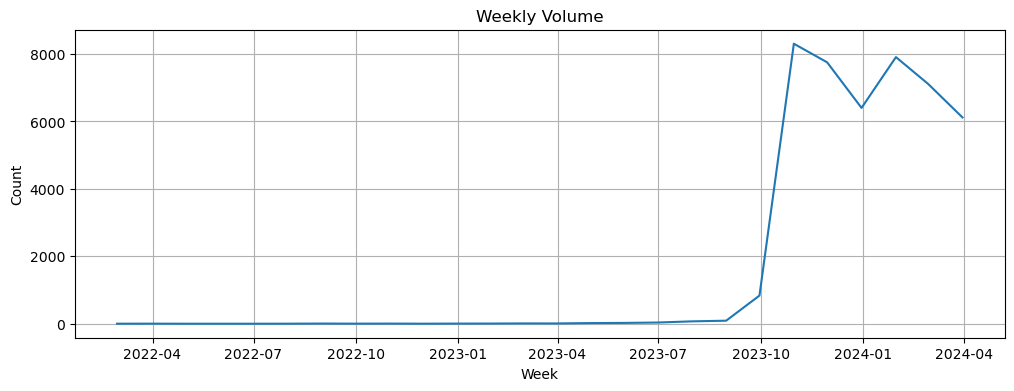

In [45]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))
plt.plot(monthly_volume)

plt.title("Weekly Volume")
plt.xlabel("Week")
plt.ylabel("Count")
plt.grid(True)

plt.show()

In [46]:
from statsmodels.tsa.stattools import adfuller
# Augmented Dickey-Fuller Test
result = adfuller(monthly_volume) 
print(result[1])  # p-value

1.0


In [47]:
train = monthly_volume[:-3]
test = monthly_volume[-3:]

In [48]:
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(train, order=(1,1,1))
model_fit = model.fit()

/home/labuser/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/home/labuser/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


In [49]:
forecast = model_fit.forecast(steps=3)
print(forecast)

2024-01-31    6789.283944
2024-02-29    6516.658391
2024-03-31    6709.067870
Freq: ME, Name: predicted_mean, dtype: float64


In [50]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(test, forecast)
print("MAE:", mae *100 )

MAE: 76970.85115718524


In [ ]:
## using seasional arima

In [52]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

model = SARIMAX(train,
                order=(1,1,1),
                seasonal_order=(1,1,1,12))

model_fit = model.fit()
forecast = model_fit.forecast(steps=3)

/home/labuser/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/home/labuser/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/home/labuser/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


In [53]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(test, forecast)
print("MAE:", mae)

MAE: 769.9892151618566


In [54]:
model_fit.forecast(steps=1)

2024-01-31    6904.157678
Freq: ME, dtype: float64

In [55]:
import numpy as np

mape = np.mean(np.abs((test - forecast) / test)) * 100
print("MAPE:", 100 - mape)

MAPE: 89.11464791872592


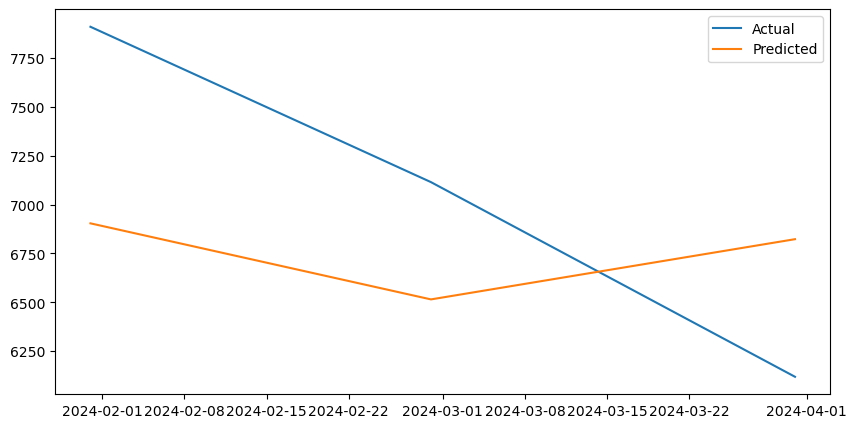

In [56]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(test.index, test, label='Actual')
plt.plot(test.index, forecast, label='Predicted')
plt.legend()
plt.show()

In [57]:
weekly_volume = df_time.resample('W').size()

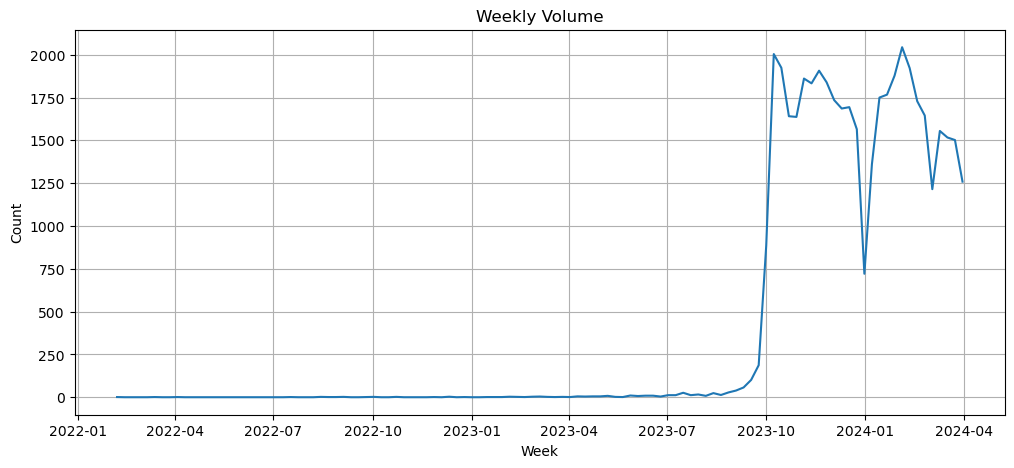

In [58]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(weekly_volume)

plt.title("Weekly Volume")
plt.xlabel("Week")
plt.ylabel("Count")
plt.grid(True)

plt.show()

In [59]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(weekly_volume)
print(result[1])  # p-value

0.8673330999080168


In [60]:
train = weekly_volume[:-12]
test = weekly_volume[-12:]

In [61]:
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(train, order=(1,1,1))
model_fit = model.fit()
forecast = model_fit.forecast(steps=12)

In [62]:
from sklearn.metrics import mean_absolute_error
forecast = model_fit.forecast(steps=12)
mae = mean_absolute_error(test, forecast)
print("MAE:", mae)

MAE: 253.1800386905555


In [63]:
from sklearn.metrics import mean_squared_error
import numpy as np

rmse = np.sqrt(mean_squared_error(test, forecast))
print(rmse)

300.3848311121669


In [64]:
import numpy as np

mape = np.mean(np.abs((test - forecast) / test)) * 100
print("MAPE:", 100-mape)

MAPE: 85.20198837833095


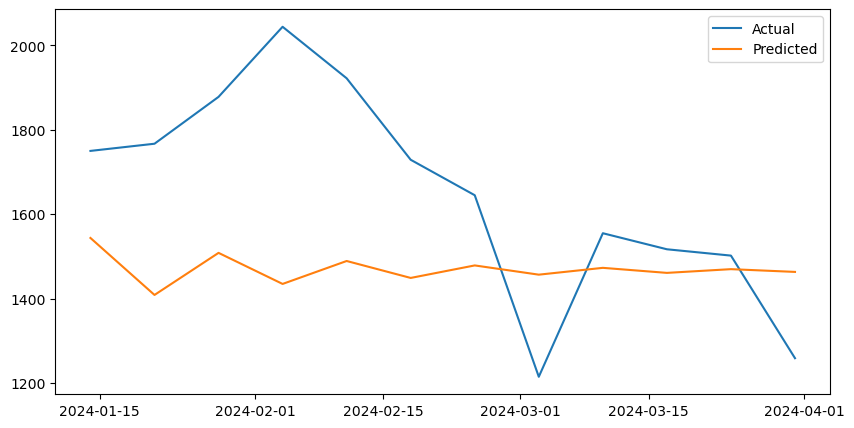

In [65]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(test.index, test, label='Actual')
plt.plot(test.index, forecast, label='Predicted')
plt.legend()
plt.show()

In [66]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

model = SARIMAX(train,
                order=(1,1,1),
                seasonal_order=(1,1,1,12))

model_fit = model.fit()
forecast = model_fit.forecast(steps=12)

/home/labuser/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/statespace/sarimax.py:997: UserWarning: Non-stationary starting seasonal autoregressive Using zeros as starting parameters.
  warn('Non-stationary starting seasonal autoregressive'


In [67]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(test, forecast)
print("MAE:", mae)

MAE: 442.83342768339725


In [68]:
import numpy as np

mape = np.mean(np.abs((test - forecast) / test)) * 100
print("MAPE:", 100-mape)

MAPE: 71.26064469998335


In [69]:
weekly_volume_recent = weekly_volume['2023-10-01':]

In [ ]:
## with weekly volume we get got better accuracy

Asset Failures and RFC Failures And Anomoly detection

In [72]:
df.head(2)

,CI_Name,CI_Cat,CI_Subcat,WBS,Status,Impact,Urgency,Priority,number_cnt,Category,KB_number,Alert_Status,No_of_Reassignments,Open_Time,Resolved_Time,Handle_Time_hrs,Closure_Code,No_of_Related_Interactions,Related_Interaction
0,SUB000508,subapplication,Web Based Application,WBS000162,Closed,3,3,4.0,0.601292,incident,KM0000553,closed,26.0,2022-02-05 13:32:00,2023-11-04 13:50:00,"3,87,16,91,111",Other,1.0,SD0000007
1,WBA000124,application,Web Based Application,WBS000088,Closed,2,2,3.0,0.415050,incident,KM0000611,closed,33.0,2022-03-12 15:44:00,2023-12-02 12:36:00,"4,35,47,86,389",Software,1.0,SD0000011


In [73]:
df.Category.unique()

array(['incident', 'request for information', 'complaint'], dtype=object)

In [74]:
rfc_df = df[df['Category'] == 'request for change']
rfc_df

,CI_Name,CI_Cat,CI_Subcat,WBS,Status,Impact,Urgency,Priority,number_cnt,Category,KB_number,Alert_Status,No_of_Reassignments,Open_Time,Resolved_Time,Handle_Time_hrs,Closure_Code,No_of_Related_Interactions,Related_Interaction


In [ ]:
## it is not possible to develop a RFC failures detection model with this data so we can detect anmoly tickets

Isolation Forest
One-Class SVM
Local Outlier Factor

In [75]:
anomoly_df = df[['No_of_Reassignments','No_of_Related_Interactions','Impact','Urgency','number_cnt']]

In [76]:
anomoly_df.head()

,No_of_Reassignments,No_of_Related_Interactions,Impact,Urgency,number_cnt
0,26.0,1.0,3,3,0.601292
1,33.0,1.0,2,2,0.415050
2,3.0,1.0,4,2,0.517551
3,13.0,1.0,3,3,0.642927
4,2.0,1.0,3,3,0.345258


In [77]:
anomoly_df['ticket_complexity'] = anomoly_df[['No_of_Reassignments', 'No_of_Related_Interactions']].sum(axis=1)

/tmp/ipykernel_3627/3710013083.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  anomoly_df['ticket_complexity'] = anomoly_df[['No_of_Reassignments', 'No_of_Related_Interactions']].sum(axis=1)


In [78]:
anomoly_df.isna().sum()

No_of_Reassignments           0
No_of_Related_Interactions    0
Impact                        0
Urgency                       0
number_cnt                    0
ticket_complexity             0
dtype: int64

In [79]:
anomoly_df['No_of_Reassignments'] = anomoly_df['No_of_Reassignments'].fillna(0)
anomoly_df.isna().sum()

/tmp/ipykernel_3627/426352058.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  anomoly_df['No_of_Reassignments'] = anomoly_df['No_of_Reassignments'].fillna(0)


No_of_Reassignments           0
No_of_Related_Interactions    0
Impact                        0
Urgency                       0
number_cnt                    0
ticket_complexity             0
dtype: int64

In [80]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [81]:
x_scaled = scaler.fit_transform(anomoly_df)

In [82]:
x_scaled

array([[10.85264922, -0.05759854, -0.39733937, -0.31114781,  0.35248395,
         7.0509833 ],
       [13.90923132, -0.05759854, -1.86683461, -1.74148748, -0.29314037,
         9.04875265],
       [ 0.80959376, -0.05759854,  1.07215587, -1.74148748,  0.06218906,
         0.48688401],
       ...,
       [-0.50036999, -0.05759854,  1.07215587,  1.11919186,  1.44852723,
        -0.36930285],
       [-0.50036999, -0.05759854, -0.39733937, -0.31114781,  0.69909324,
        -0.36930285],
       [-0.50036999, -0.05759854, -1.86683461, -1.74148748,  1.39601965,
        -0.36930285]])

### For this dataset:

Isolation Forest

is the best choice because:

Works well with many samples

Handles noise

Scales well to large datasets

Your dataset has ~45k tickets, so it's ideal.

In [83]:
from sklearn.ensemble import IsolationForest

model = IsolationForest(
    contamination='auto',
    random_state=42
)

model.fit(x_scaled)

anomoly_df['anomaly'] = model.predict(x_scaled)

/tmp/ipykernel_3627/1182492864.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  anomoly_df['anomaly'] = model.predict(x_scaled)


In [84]:
anomoly_df.head(2)

,No_of_Reassignments,No_of_Related_Interactions,Impact,Urgency,number_cnt,ticket_complexity,anomaly
0,26.0,1.0,3,3,0.601292,27.0,-1
1,33.0,1.0,2,2,0.415050,34.0,-1


In [85]:
anomoly_df[anomoly_df['anomaly']==-1]

,No_of_Reassignments,No_of_Related_Interactions,Impact,Urgency,number_cnt,ticket_complexity,anomaly
0,26.0,1.0,3,3,0.601292,27.0,-1
1,33.0,1.0,2,2,0.415050,34.0,-1
2,3.0,1.0,4,2,0.517551,4.0,-1
3,13.0,1.0,3,3,0.642927,14.0,-1
5,4.0,1.0,3,3,0.006676,5.0,-1
...,...,...,...,...,...,...,...
46553,0.0,1.0,4,2,0.123493,1.0,-1
46569,0.0,1.0,2,2,0.022713,1.0,-1
46590,0.0,1.0,4,2,0.767070,1.0,-1
46592,2.0,1.0,2,2,0.464394,3.0,-1


<Axes: xlabel='anomaly', ylabel='No_of_Reassignments'>

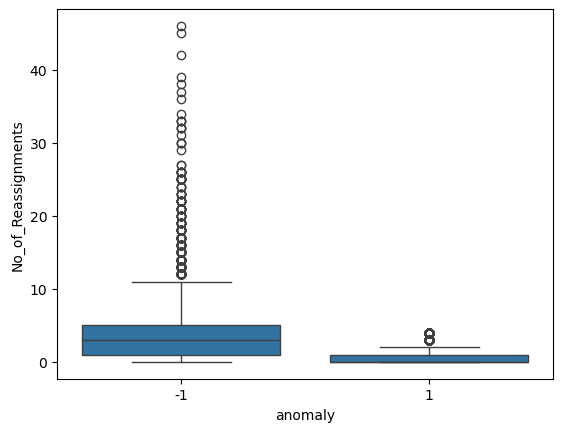

In [86]:
import seaborn as sns

sns.boxplot(x=anomoly_df['anomaly'], y=anomoly_df['No_of_Reassignments'])

In [87]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(x_scaled)

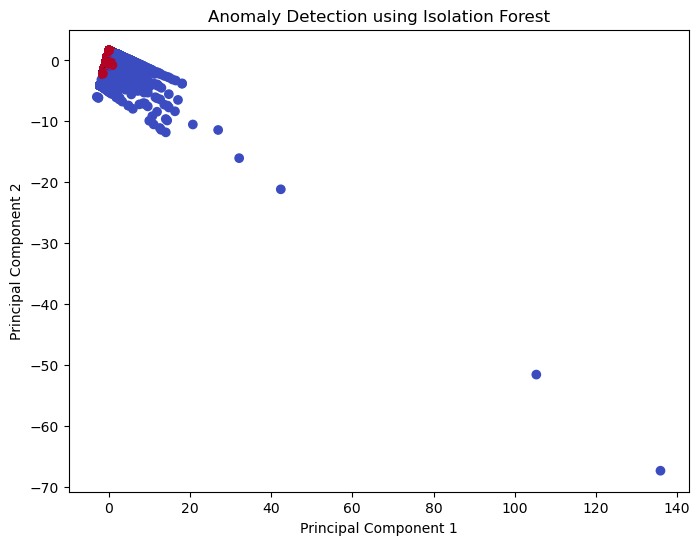

In [88]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=anomoly_df['anomaly'],
    cmap='coolwarm'
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.title("Anomaly Detection using Isolation Forest")

plt.show()

Text(0.5, 1.0, 'Anomaly Score Distribution')

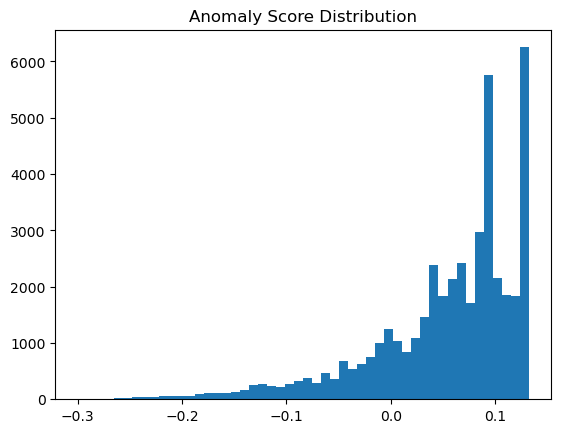

In [89]:
scores = model.decision_function(x_scaled)

plt.hist(scores, bins=50)
plt.title("Anomaly Score Distribution")

In [90]:
anomoly_df.head(1)

,No_of_Reassignments,No_of_Related_Interactions,Impact,Urgency,number_cnt,ticket_complexity,anomaly
0,26.0,1.0,3,3,0.601292,27.0,-1


In [91]:
model.predict(scaler.transform([[60,40,3,3,0.6,7]]))

/home/labuser/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([-1])

In [92]:
anomoly_df[anomoly_df['anomaly']==-1].sort_values(
    'No_of_Reassignments',
    ascending=False
).head()

,No_of_Reassignments,No_of_Related_Interactions,Impact,Urgency,number_cnt,ticket_complexity,anomaly
313,46.0,1.0,4,4,0.136042,47.0,-1
3915,45.0,2.0,4,4,0.120097,47.0,-1
355,42.0,1.0,4,4,0.256527,43.0,-1
437,39.0,2.0,4,4,0.012971,41.0,-1
5755,38.0,1.0,4,4,0.148994,39.0,-1


In [93]:
for c in [0.01,0.02,0.05]:
    model = IsolationForest(contamination=c, random_state=42)
    preds = model.fit_predict(x_scaled)
    print(c, (preds==-1).sum())

0.01 448
0.02 895
0.05 2237


In [ ]:
## finally we succed in this task also because we get good anomoly prediction successfully acheived 

### Auto Tagging 

In [97]:
sampleDf = pd.read_csv('Data/service_now/sample.csv')

In [98]:
sampleDf.head(2)

,category,state,closed_at,opened_at,closed_by,number,sys_updated_by,location,assigned_to,caller_id,sys_updated_on,short_description,assignment_group,priority
0,Software,Closed,2023-01-03 11:04:00.000000000,2023-01-02 11:04:00,Charlie Whitherspoon,INC0000000000,admin,UK,Beth Anglin,David Loo,2023-01-03 11:04:00.000000000,Application error on office software,Software,2 - High
1,Hardware,Closed,2023-01-11 01:17:39.128189467,2023-01-03 10:19:00,Beth Anglin,INC0000000001,employee,Australia,Luke Wilson,Don Goodliffe,2023-01-11 01:17:39.128189467,Printer error at Printer-id: Printer546 in Aus...,Hardware,2 - High


In [99]:
textdf = sampleDf[['category','short_description']]

In [100]:
textdf.head(2)

,category,short_description
0,Software,Application error on office software
1,Hardware,Printer error at Printer-id: Printer546 in Aus...


In [101]:
textdf.category.unique()

array(['Software', 'Hardware', 'Network', 'Inquiry / Help', 'Database'],
      dtype=object)

In [102]:
textdf['category'].value_counts()

category
Hardware          336
Network            51
Software           41
Database           40
Inquiry / Help     32
Name: count, dtype: int64

In [103]:
textdf.shape

(500, 2)

In [104]:
import nltk

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package punkt to /home/labuser/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /home/labuser/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /home/labuser/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /home/labuser/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /home/labuser/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [105]:
import re
import nltk
from nltk.stem import WordNetLemmatizer, PorterStemmer
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

lemmatizer = WordNetLemmatizer()
stemmer = PorterStemmer()
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = text.lower()
    
    # remove special characters
    text = re.sub(r'[^a-zA-Z ]', '', text)

    words = word_tokenize(text)

    words = [stemmer.stem(lemmatizer.lemmatize(word)) for word in words if word not in stop_words]
    
    # join words back
    return " ".join(words)

textdf['short_description'] = textdf['short_description'].apply(clean_text)

/tmp/ipykernel_3627/193085687.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  textdf['short_description'] = textdf['short_description'].apply(clean_text)


In [106]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

textdf.category = le.fit_transform(textdf['category'])


/tmp/ipykernel_3627/987090590.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  textdf.category = le.fit_transform(textdf['category'])


In [107]:
X = textdf['short_description']
Y = textdf['category']

In [108]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42, stratify=Y
)

In [109]:
X_test.shape, X_train.shape, y_train.shape, y_test.shape

((100,), (400,), (400,), (100,))

In [110]:
# X_train

In [111]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    stop_words='english',
    ngram_range=(1,2),
    max_df=0.9,
    min_df=2
)

x_train = vectorizer.fit_transform(X_train)
x_train

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 1834 stored elements and shape (400, 204)>

In [112]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB

model = LogisticRegression(
    class_weight='balanced',
    # solver='lbfgs',
    max_iter=2000
)

nbmodel = MultinomialNB()

model.fit(x_train, y_train)
nbmodel.fit(x_train, y_train)

MultinomialNB()

In [113]:
from sklearn.metrics import classification_report

#Precision = TP / (TP + FP)
#Recall = TP / (TP + FN)
#F1 = 2 * (precision * recall) / (precision + recall)

y_pred = model.predict(vectorizer.transform(X_test))

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.89      1.00      0.94         8
           1       0.98      0.94      0.96        67
           2       1.00      0.86      0.92         7
           3       1.00      1.00      1.00        10
           4       0.73      1.00      0.84         8

    accuracy                           0.95       100
   macro avg       0.92      0.96      0.93       100
weighted avg       0.96      0.95      0.95       100



In [114]:
from sklearn.metrics import classification_report

#Precision = TP / (TP + FP)
#Recall = TP / (TP + FN)
#F1 = 2 * (precision * recall) / (precision + recall)

y_pred = nbmodel.predict(vectorizer.transform(X_test))

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.62      0.77         8
           1       0.94      1.00      0.97        67
           2       1.00      0.86      0.92         7
           3       0.91      1.00      0.95        10
           4       1.00      0.88      0.93         8

    accuracy                           0.95       100
   macro avg       0.97      0.87      0.91       100
weighted avg       0.95      0.95      0.95       100



In [115]:
ans = model.predict(vectorizer.transform([clean_text("Unable to connect to VPN after update")]))
ans

array([3])

In [116]:
le.inverse_transform(ans)

array(['Network'], dtype=object)

In [ ]:
## here our model predicting well on category to tag automatically on tickets but this is not enough data for this model 
## we can do better with more data